In [1]:
# if necessary, install NeuralGCM and dependencies
# ! pip install -q -U neuralgcm dinosaur-dycore gcsfs

In [2]:
# %pip install -U "jax[cuda12]"==0.4.30 -i https://pypi.tuna.tsinghua.edu.cn/simple   
# 其他的版本会报错，这里是先装的0.4.35，不卸载，再装0.4.30

In [3]:
# q
# 需要先装cmake, git, poetry, 在python=3.10下运行

# Forecasting quick start

This notebook uses ERA5 data and pretrained NeuralGCM model to make a weather forecast.

The forecast is made in 3 steps:
1. Slice of ERA5 data is regridded to model resolution
2. NeuralGCM model state is initialized and rolled out
3. Predictions and reference trajectory are combined for visualization

By default the notebook uses intermediate deterministic NeuralGCM 1.4° model. Other available checkpoints include deterministic 0.7°, 2.8° and stochastic 1.4° NeuralGCM variations.

```{tip}
You can run this notebook yourself in [Google Colab](https://colab.research.google.com/github/google-research/neuralgcm/blob/main/docs/inference_demo.ipynb). We recommend using a GPU or TPU runtime due to high memory and compute requirements.
```

In [4]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5,6'
device_ids = [0, 1]

import gcsfs
import jax
import numpy as np
import pickle
import xarray

from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm

print(jax.devices())
gcs = gcsfs.GCSFileSystem(token='anon')

[cuda(id=0), cuda(id=1)]


## Load a pre-trained NeuralGCM model

```{caution}
Trained model weights are licensed for non-commercial use, under the Creative Commons [Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/) license (CC BY-NC-SA 4.0).
```

Pre-trained model checkpoints from the NeuralGCM paper are [available for download](https://console.cloud.google.com/storage/browser/gresearch/neuralgcm/04_30_2024) on Google Cloud Storage:

- Deterministic models:
    - `gs://gresearch/neuralgcm/04_30_2024/neural_gcm_dynamic_forcing_deterministic_0_7_deg.pkl`
    - `gs://gresearch/neuralgcm/04_30_2024/neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl`
    - `gs://gresearch/neuralgcm/04_30_2024/neural_gcm_dynamic_forcing_deterministic_2_8_deg.pkl`
- Stochastic models:
    - `gs://gresearch/neuralgcm/04_30_2024/neural_gcm_dynamic_forcing_stochastic_1_4_deg.pkl`



In [ ]:
model_name = 'neuralgcm_04_30_2024_neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl'  #@param ['neural_gcm_dynamic_forcing_deterministic_0_7_deg.pkl', 'neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl', 'neural_gcm_dynamic_forcing_deterministic_2_8_deg.pkl', 'neural_gcm_dynamic_forcing_stochastic_1_4_deg.pkl'] {type: "string"}

# 载入模型权重
with open(f'/nfs/gpu_homes/gpu09/home/zhangjing/Code/NeuralGCM/pkl/{model_name}', 'rb') as f:
   ckpt = pickle.load(f)

In [6]:
model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)

## Load ERA5 data from GCP/Zarr

See {doc}`datasets` for details.

Select out a few days of data:

数据准备-使用本地数据ERA5
使用本地数据驱动NGCM需要进行一些预处理，包括变量名的规范化、变量选取、插值与缺失值填补。

变量名规范化部分官方使用gcsfs中的get_mapper函数进行处理，但我初次测试时这个函数屡屡报错，因为懒得调试愤而使用以下dict手动对变量名进行调整，使其匹配官方要求。

注意：如果你的ERA5数据变量名与dict的key不同，需要手动检查替换（可以读入后先check一波），或者参考官方quick start，考虑使用gcsfs的那个get_mapper函数。

In [7]:
var_dict = {
    'siconc':'sea_ice_cover', 
    'sst':'sea_surface_temperature',
    'u':'u_component_of_wind', 
    'v':'v_component_of_wind', 
    'z':'geopotential', 
    't':'temperature', 
    'q':'specific_humidity', 
    'ciwc':'specific_cloud_ice_water_content', 
    'clwc':'specific_cloud_liquid_water_content',
}

读取数据，我的surface与pressure数据分了两个文件下载，所以分别读取后merge。

又由于我下载ERA5的时候操作失误导致两个文件时次对不上（surface下多了），所以手动选取时段以保证对齐

In [8]:
# create a xarray.Dataset with required variables for NeuralGCM
import pandas as pd #用一下date_range函数

path = ['/nfs/gpu_homes/gpu09/home/zhangjing/Code/NeuralGCM/era5/surface_240709_240712.nc','/nfs/gpu_homes/gpu09/home/zhangjing/Code/NeuralGCM/era5/pressure_240709_240712.nc']

era5_pressure = xarray.open_dataset(path[1]).sel(time=pd.date_range('2024-7-09 00:00:00','2024-7-12 23:00:00',freq='h'))
era5_surface = xarray.open_dataset(path[0]).sel(time=pd.date_range('2024-7-09 00:00:00','2024-7-12 23:00:00',freq='h'))

检查一下数据。注意如果你的数据里有expver这个维度也要预先给它去掉，我们这份数据里是没有的

In [9]:
era5_pressure

<xarray.Dataset> Size: 13GB
Dimensions:    (longitude: 360, latitude: 181, level: 37, time: 96)
Coordinates:
  * longitude  (longitude) float32 1kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
  * latitude   (latitude) float32 724B 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * level      (level) int32 148B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * time       (time) datetime64[ns] 768B 2024-07-09 ... 2024-07-12T23:00:00
Data variables:
    z          (time, level, latitude, longitude) float64 2GB ...
    ciwc       (time, level, latitude, longitude) float64 2GB ...
    clwc       (time, level, latitude, longitude) float64 2GB ...
    q          (time, level, latitude, longitude) float64 2GB ...
    t          (time, level, latitude, longitude) float64 2GB ...
    u          (time, level, latitude, longitude) float64 2GB ...
    v          (time, level, latitude, longitude) float64 2GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-07-24 03:49:25 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [10]:
era5_surface

<xarray.Dataset> Size: 100MB
Dimensions:    (longitude: 360, latitude: 181, time: 96)
Coordinates:
  * longitude  (longitude) float32 1kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
  * latitude   (latitude) float32 724B 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * time       (time) datetime64[ns] 768B 2024-07-09 ... 2024-07-12T23:00:00
Data variables:
    siconc     (time, latitude, longitude) float64 50MB ...
    sst        (time, latitude, longitude) float64 50MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-07-25 02:54:44 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

拼接两部分输入数据，按模型要求重命名，提取模型所需变量

In [11]:
full_era5 = xarray.merge([era5_pressure,era5_surface]) #数据拼接

#变量名规范化，官方这里使用的是gcs.get_mapper(filepath)函数直接在读取数据时完成重命名，我们这里逃课
full_era5 = full_era5.rename_vars(var_dict) 
#保留模型所需变量
full_era5 = full_era5[model.input_variables + model.forcing_variables]

print("数据集的时间范围为", full_era5.time.min(), full_era5.time.max())
full_era5  # 处理前的数据集, 仅进行了变量重命名


数据集的时间范围为 <xarray.DataArray 'time' ()> Size: 8B
array('2024-07-09T00:00:00.000000000', dtype='datetime64[ns]') <xarray.DataArray 'time' ()> Size: 8B
array('2024-07-12T23:00:00.000000000', dtype='datetime64[ns]')


<xarray.Dataset> Size: 13GB
Dimensions:                              (time: 96, level: 37, latitude: 181,
                                          longitude: 360)
Coordinates:
  * longitude                            (longitude) float32 1kB 0.0 ... 359.0
  * latitude                             (latitude) float32 724B 90.0 ... -90.0
  * level                                (level) int32 148B 1 2 3 ... 975 1000
  * time                                 (time) datetime64[ns] 768B 2024-07-0...
Data variables:
    geopotential                         (time, level, latitude, longitude) float64 2GB ...
    specific_humidity                    (time, level, latitude, longitude) float64 2GB ...
    temperature                          (time, level, latitude, longitude) float64 2GB ...
    u_component_of_wind                  (time, level, latitude, longitude) float64 2GB ...
    v_component_of_wind                  (time, level, latitude, longitude) float64 2GB ...
    specific_cloud_ice_water_content     (time, level, latitude, longitude) float64 2GB ...
    specific_cloud_liquid_water_content  (time, level, latitude, longitude) float64 2GB ...
    sea_ice_cover                        (time, latitude, longitude) float64 50MB ...
    sea_surface_temperature              (time, latitude, longitude) float64 50MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-07-24 03:49:25 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

regrid与fill¶
这部分照搬官方文档即可

In [12]:
# 构建regridder
from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils

full_era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes['latitude'],
    longitude_nodes=full_era5.sizes['longitude'],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
# Other available regridders include BilinearRegridder and NearestRegridder.
regridder = horizontal_interpolation.ConservativeRegridder(
    full_era5_grid, model.data_coords.horizontal, skipna=True
)

# 需要数据切片的话可以在这里进行，数据太大regrid会非常慢
sliced_era5 = full_era5
# 插值处理，输出为regridded
regridded = xarray_utils.regrid(sliced_era5, regridder)
regridded

2025-11-13 15:12:17.916525: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


<xarray.Dataset> Size: 3GB
Dimensions:                              (time: 96, level: 37, longitude: 256,
                                          latitude: 128)
Coordinates:
  * level                                (level) int32 148B 1 2 3 ... 975 1000
  * time                                 (time) datetime64[ns] 768B 2024-07-0...
  * longitude                            (longitude) float64 2kB 0.0 ... 358.6
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
Data variables:
    geopotential                         (time, level, longitude, latitude) float32 466MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 466MB ...
    temperature                          (time, level, longitude, latitude) float32 466MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 466MB ...
    v_component_of_wind                  (time, level, longitude, latitude) float32 466MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 466MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 466MB ...
    sea_ice_cover                        (time, longitude, latitude) float32 13MB ...
    sea_surface_temperature              (time, longitude, latitude) float32 13MB ...

可视化检查regrid效果

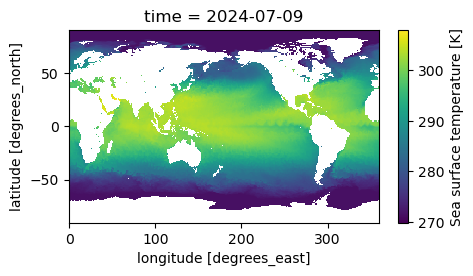

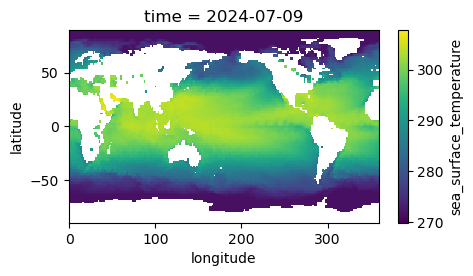

In [13]:
%matplotlib inline

sliced_era5.sea_surface_temperature.isel(time=0).plot(x='longitude', y='latitude', aspect=2, size=2.5);
regridded.sea_surface_temperature.isel(time=0).plot(x='longitude', y='latitude', aspect=2, size=2.5);

fillna并检查效果，这里也是照搬官方文档

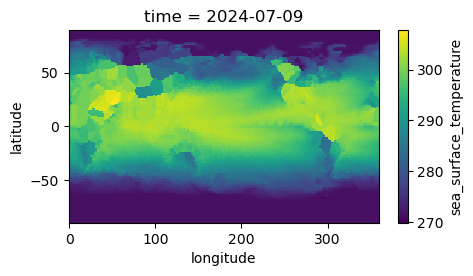

In [14]:
regridded_and_filled = xarray_utils.fill_nan_with_nearest(regridded)
regridded_and_filled.sea_surface_temperature.isel(time=0).plot(x='longitude', y='latitude', aspect=2, size=2.5)

In [15]:
regridded_and_filled

<xarray.Dataset> Size: 3GB
Dimensions:                              (level: 37, time: 96, longitude: 256,
                                          latitude: 128)
Coordinates:
  * level                                (level) int32 148B 1 2 3 ... 975 1000
  * time                                 (time) datetime64[ns] 768B 2024-07-0...
  * longitude                            (longitude) float64 2kB 0.0 ... 358.6
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
Data variables:
    geopotential                         (time, level, longitude, latitude) float32 466MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 466MB ...
    temperature                          (time, level, longitude, latitude) float32 466MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 466MB ...
    v_component_of_wind                  (time, level, longitude, latitude) float32 466MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 466MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 466MB ...
    sea_ice_cover                        (time, longitude, latitude) float32 13MB ...
    sea_surface_temperature              (time, longitude, latitude) float32 13MB ...

至此数据已经ready to serve

## 开始预测
这里可以修改的地方有：

inner_steps: 输出时间间隔，设为1=逐小时输出（原为24
outer_steps：输出总时次，设为2*24以输出共48小时（原为4x24
inputs阶段的.isel(time=？)：输入用的时次，这里输入第一个时次，后面的时次用于对比预报效果，这里我没改
其他我没有改动，可以参考Deep-dive into trained models - NeuralGCM documentation进行进一步调整

In [16]:
import numpy as np

inner_steps = 1  # save model outputs once every 24 hours
outer_steps = 4 * 24 // inner_steps  # total of 4 days
timedelta = np.timedelta64(1, 'h') * inner_steps
times = (np.arange(outer_steps) * inner_steps)  # time axis in hours


In [17]:
# initialize model state
inputs = model.inputs_from_xarray(regridded_and_filled.isel(time=0))
input_forcings = model.forcings_from_xarray(regridded_and_filled.isel(time=0))
rng_key = jax.random.key(42)  # optional for deterministic models


In [18]:
# 这里说明input格式为字典, 这里使用操作字典的函数, 显示该字典的所有的键
inputs.keys()

dict_keys(['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content', 'sim_time'])

In [19]:
initial_state = model.encode(inputs, input_forcings, rng_key)

In [20]:
initial_state

ModelState(state=State(vorticity=Array([[[ 5.56474645e-03, -3.57633969e-03, -1.72155127e-01, ...,
          1.87648275e-09,  9.93617633e-09,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -3.50214355e-03,  1.89927872e-04, ...,
         -3.39060030e-10, -1.82263737e-09, -0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          6.28503971e-10, -3.67619624e-09,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00, -1.35703182e-09, -0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00, -1.78237047e-09,  0.00000000e+00]],

       [[-5.86420903e-03, -1.37501117e-02, -1.21624626e-01, ...,
          1.27651312e-08,  8.75652495e-10,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
     

In [21]:
# use persistence for forcing variables (SST and sea ice cover)
all_forcings = model.forcings_from_xarray(regridded_and_filled.head(time=1))


In [ ]:
all_forcings

In [22]:
# make forecast
final_state, predictions = model.unroll(
    initial_state,
    all_forcings,
    steps=outer_steps,
    timedelta=timedelta,
    start_with_input=True,
)
predictions_ds = model.data_to_xarray(predictions, times=times)

## 效果对比
拼合ERA5与模型输出
data_inner_steps应该是用于确认数据时间分辨率的，文档内没找到具体说明，保险起见设为与预报阶段的inner_steps一致

In [23]:
data_inner_steps = 1
# Selecting ERA5 targets from exactly the same time slice
target_trajectory = model.inputs_from_xarray(
    regridded_and_filled
    .thin(time=(inner_steps // data_inner_steps))
    .isel(time=slice(outer_steps))
)
target_data_ds = model.data_to_xarray(target_trajectory, times=times)

combined_ds = xarray.concat([target_data_ds, predictions_ds], 'model')
combined_ds.coords['model'] = ['ERA5', 'NeuralGCM']

In [24]:
combined_ds

<xarray.Dataset> Size: 7GB
Dimensions:                              (model: 2, time: 96, level: 37,
                                          longitude: 256, latitude: 128)
Coordinates:
  * longitude                            (longitude) float64 2kB 0.0 ... 358.6
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * time                                 (time) int64 768B 0 1 2 3 ... 93 94 95
  * model                                (model) <U9 72B 'ERA5' 'NeuralGCM'
Data variables:
    sim_time                             (model, time) float64 2kB 2.095e+05 ...
    specific_cloud_liquid_water_content  (model, time, level, longitude, latitude) float32 931MB ...
    specific_humidity                    (model, time, level, longitude, latitude) float32 931MB ...
    v_component_of_wind                  (model, time, level, longitude, latitude) float32 931MB ...
    temperature                          (model, time, level, longitude, latitude) float32 931MB ...
    geopotential                         (model, time, level, longitude, latitude) float32 931MB ...
    specific_cloud_ice_water_content     (model, time, level, longitude, latitude) float32 931MB ...
    u_component_of_wind                  (model, time, level, longitude, latitude) float32 931MB ...
Attributes:
    longitude_wavenumbers:     128
    total_wavenumbers:         129
    longitude_nodes:           256
    latitude_nodes:            128
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    1.0
    spherical_harmonics_impl:  RealSphericalHarmonicsWithZeroImag
    spmd_mesh:                 
    centers:                   [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, ...
    horizontal_grid_type:      Grid
    vertical_grid_type:        PressureCoordinates

## 可视化检查
随便画几个图看一下，具体效果大家可以把combined_ds保存成nc文件慢慢检查

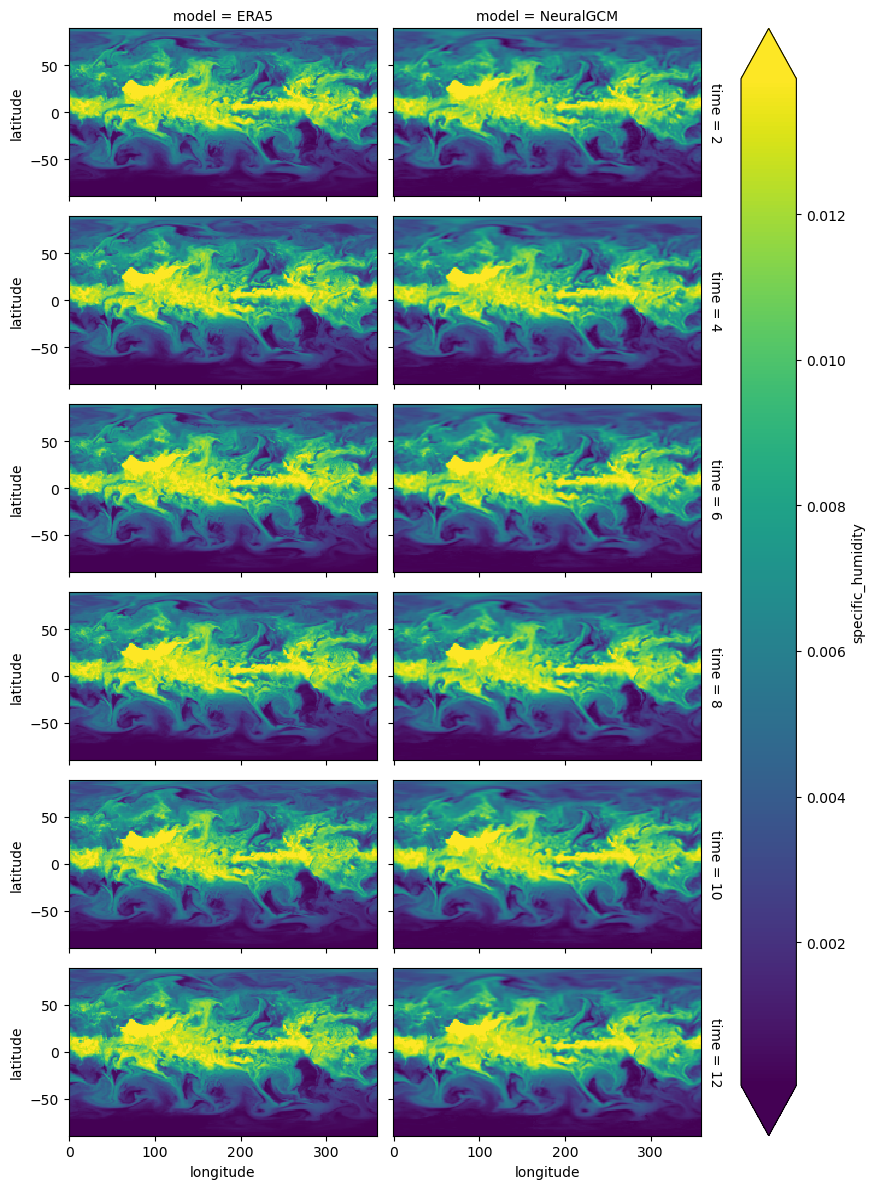

In [25]:
# Visualize ERA5 vs NeuralGCM trajectories
combined_ds.specific_humidity.sel(level=850,time=slice(2,12+1,2)).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2
);

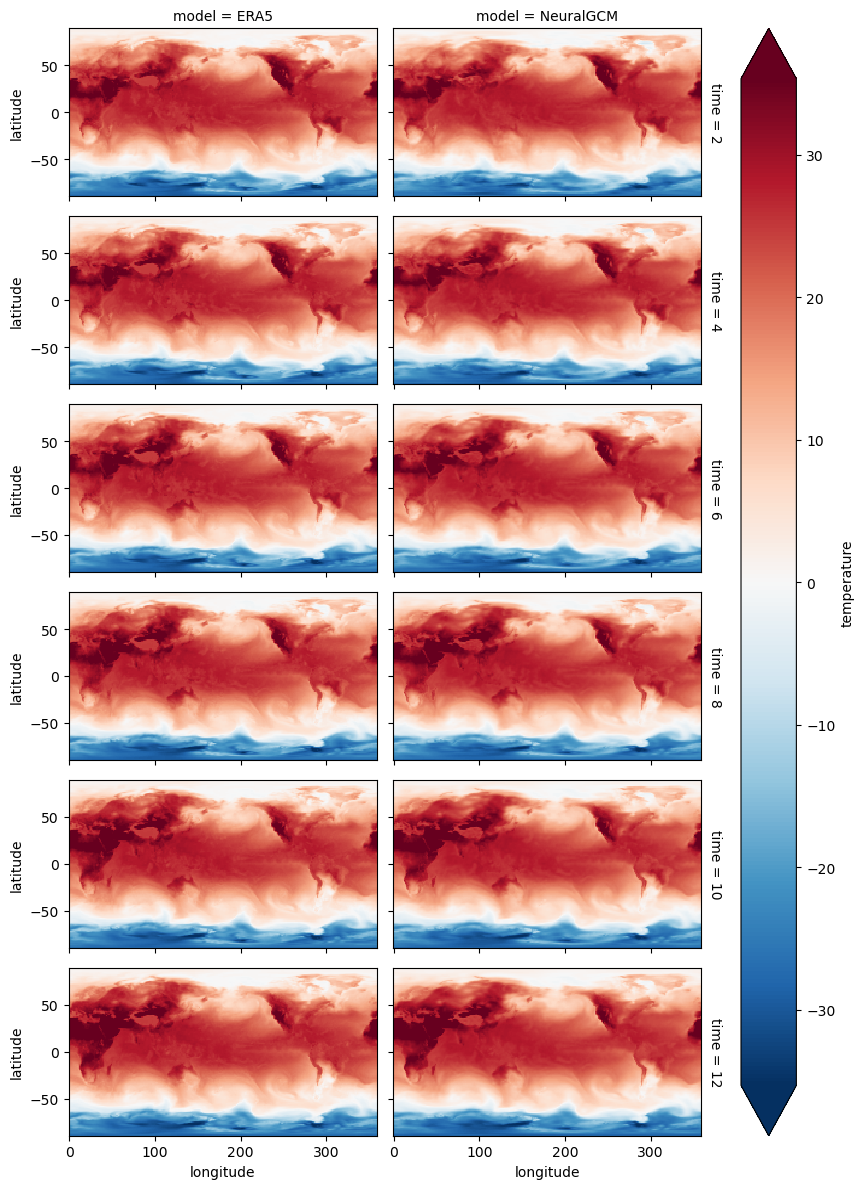

In [26]:
test_temperature = combined_ds.temperature-273.15

test_temperature.sel(level=1000,time=slice(2,12+1,2)).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2
);

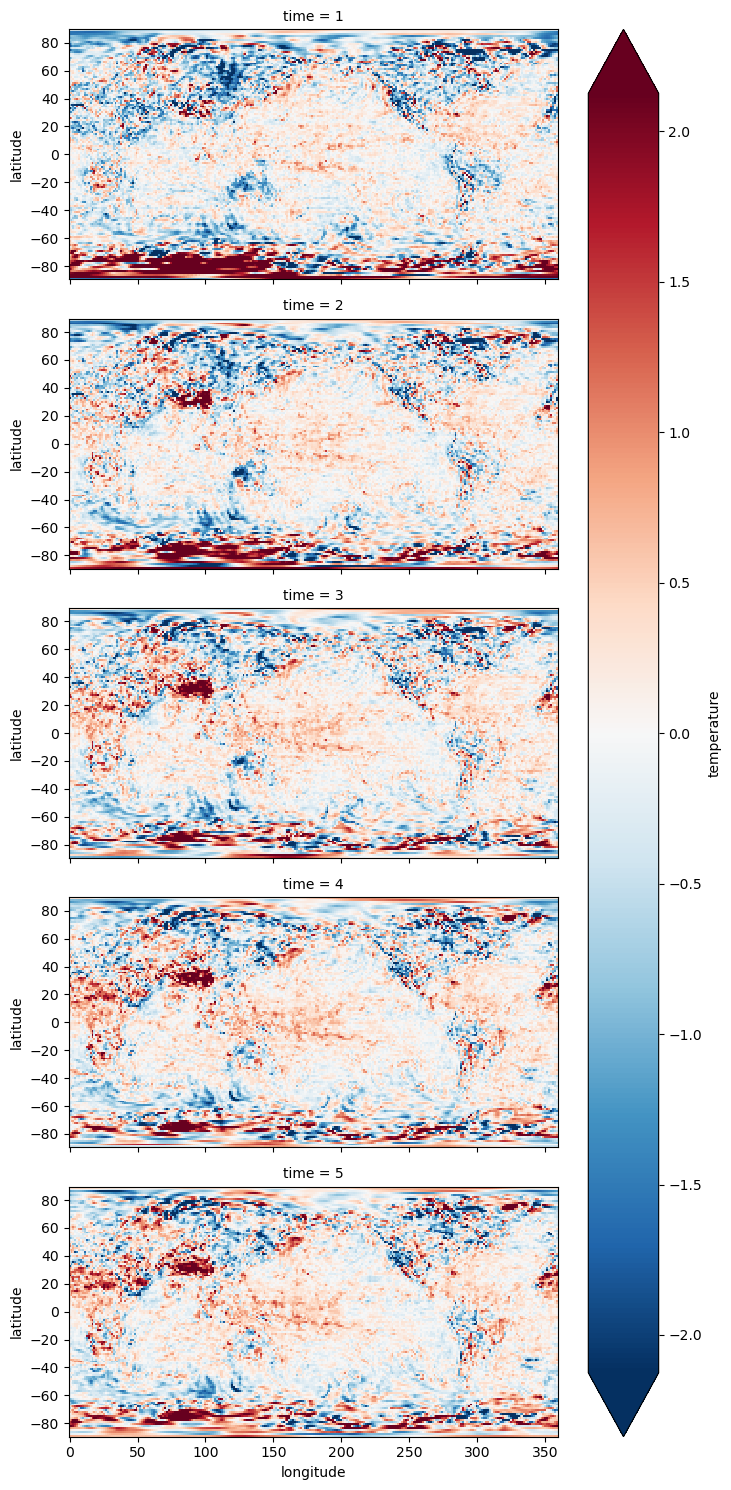

In [27]:
test_t1000 = test_temperature.sel(level=1000,time=slice(1,4+1,1))
test_t_diff = test_t1000.sel(model='NeuralGCM')-test_t1000.sel(model='ERA5')
test_t_diff.plot(
    x='longitude', y='latitude', row='time', robust=True, aspect=2, size=3
);

In [28]:
#era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
#full_era5 = xarray.open_zarr(gcs.get_mapper(era5_path), chunks=None)

In [29]:
demo_start_time = '2024-07-14'
demo_end_time = '2024-02-18'
data_inner_steps = 24  # process every 24th hour

In [30]:
sliced_era5 = (
    full_era5
    [model.input_variables + model.forcing_variables]
    .pipe(
        xarray_utils.selective_temporal_shift,
        variables=model.forcing_variables,
        time_shift='24 hours',
    )
    .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
    .compute()
)

print('sliced_era5 time size:', sliced_era5.sizes['time'])
print('sliced_era5 time values:', sliced_era5.time.values)


sliced_era5 time size: 0
sliced_era5 time values: []
